# Probability of wildtype extinction and proportion of time population contains Wolbachia infection for range of number of males and females released
## Abby Barlow, The University of Bath
Uses 'SSA__hhold_release.jl' for the stochastic simulation implementation which is called from 'single_release_hhold_general.jl'.
To use the already produced results see 'mixed_single_rel.csv' for the required zip file names.

Import libraries

In [1]:
### importing the required libraries
using CSV
using DataFrames
using Statistics
using Plots
using DataStructures  # For the Counter function
using CodecZlib
using Tar
using Measures

### Key simulation parameters

JOB_ID defines the job run from the HPC and is used to identify each set of results. These are detailed in 'Initial_release_experiments.csv'.

gamma, rho, tau and alpha are the mosquito dispersal parameters.

num_simulations defines the number of simulation runs of the SSA for each result.

rel_type defines the release scale. 'relhhold' is for household scale releases and 'relcom' is for community scale releases.

In [2]:
### change this to the job id for the experiment you want to analyze
## or the name you want to give the folder where all the extracted data files will be stored
JOB_ID = 67140322

### make sure to write dispersal parameters as floats to keep file name consistent ###

## vary these for different dispersal scenarios
gamma = 0.33    # dispersal rate from release site to household
rho = 0.33     # rate visit the households
tau = 0.33      # rate leave the households
alpha = 0.1     # dispersal rate of females moving from household directly to another household

rel_fem = 2
rel_male = 5
delta_rel = 50

num_simulations = 100  # number of realisations of SSA to run, 10,000 is a good number for the paper
rel_type = "relhhold" # release scale

"relhhold"

Parameter dictionary

In [3]:
fem_w0 = 0  # how many wildtypes and infected mosquitoes starting off with
male_w0 = 0
fem_m0 = 8
male_m0 = 8
# initialise free pool
m_free0 = 0 # no. of free wild-type
w_free0 = 0 # no. of free Wolbachia

phi = 0.85      # wolbachia fitness effect on birth rate
K = 30          # carrying capacity of mosquitoes per household
d = 12/100      # death rate of mosquitoes
k = 0.3         # larval density parameter
h = 0.19*100^k  # larval density parameter
b = 0.54        # per capita birth rate of mosquitoes (wildtypes)
H = 100         # number of households
u = 1           # vertical transmission probability
v = 1           # CI effect, proportion of non-viable offspring from infected male and wildtype female birth

rel_t = 150   # initial release time

## remember this is per household for the household releases so should use smaller release numbers

t_start = 0    
t_end = 1000   # start time and end time (days) of simulation

result_length = length(t_start:t_end) # number of time points to store results
weeks = round(Int,result_length/7)    # number of weeks to store results

parameters = Dict(           # dictionary of parameters
    :fem_m0 => fem_m0,
    :male_m0 => male_m0,
    :fem_w0 => fem_w0,
    :male_w0 => male_w0,
    :m_free0 => m_free0,
    :w_free0 => w_free0,
    :rho => rho,
    :phi => phi,
    :b => b,
    :K => K,
    :d => d,
    :h => h,
    :k => k,
    :u => u,
    :v => v,
    :tau => tau,
    :H => H,
    :t_start => t_start,
    :t_end => t_end,
    :delta_rel => delta_rel,
    :gamma => gamma,
    :alpha => alpha,
    :rel_t => rel_t
)

Dict{Symbol, Real} with 23 entries:
  :b       => 0.54
  :alpha   => 0.1
  :gamma   => 0.33
  :m_free0 => 0
  :rho     => 0.33
  :t_start => 0
  :h       => 0.756404
  :rel_t   => 150
  :male_w0 => 0
  :fem_m0  => 8
  :K       => 30
  :phi     => 0.85
  :fem_w0  => 0
  :d       => 0.12
  :k       => 0.3
  :v       => 1
  :u       => 1
  :male_m0 => 8
  :tau     => 0.33
  ⋮        => ⋮

Converts dispersal parameters to strings for saving figures.

In [4]:
### Convert dispersal parameters to a string and remove the decimal point
## We will use this to call the correct data files
rho_str = replace(string(rho), "." => "")
tau_str = replace(string(tau), "." => "")
gamma_str = replace(string(gamma), "." => "")
alpha_str = replace(string(alpha), "." => "")

"01"

Function to find job id from HPC run that corresponds to specific release result.

In [10]:
# Read the CSV file into a DataFrame
JOBS_DF = CSV.read("../single_rel_mixed_hhold\\mixed_single_rel.csv", DataFrame)

function find_job_id(df::DataFrame, rel_fem_value, rel_male_value)
    """Function to find the JOB_ID for given rel_fem (number of females released) and rel_male 
    (number of males released)."""
    found = false  # initialize a flag to check if a match is found
    for row in eachrow(df)  # iterate through each row of the DataFrame
        # Check if the row matches the specified release values
        if !ismissing(row[Symbol("job no.")]) &&
           row[Symbol("no. females")] == rel_fem_value && row[Symbol("no. males")] == rel_male_value
            return row[Symbol("job no.")] # Return the job id if a match is found
            found = true  # Set the flag to true if a match is found
            break
        else   # If the row does not match, continue to the next row
            continue
        end
    end # Return nothing if no matching row is found
    if !found
        return nothing
    end
end

find_job_id (generic function with 1 method)

Counts the number of columns that include a zero i.e. number of simulations where wildtypes goes extinct in the total metapopulation.

In [12]:
function count_columns_with_zero(df::DataFrame)
"""Function to count columns with zero in it."""
    count_zeros = 0  # initialize a counter for columns with zero
    for col in eachcol(df)   # iterate through each column of the DataFrame
        if 0.0 in col  # check if the column contains a zero
            count_zeros += 1  # increment the counter if a zero is found
        end
    end
    return count_zeros   # return the count of columns with zero
end

ratio = zeros(11,11)   # Initialize a matrix to store the ratio of columns with zero
for male in 0:10     # Loop through the male release sizes
    for fem in 0:5   # Loop through the female
        JOB_ID = find_job_id(JOBS_DF, fem, male)   # Find the job ID for the current release sizes
        println(fem, "  ", male, "  ", JOB_ID)
        if JOB_ID != nothing  # Check if a valid JOB_ID was found
            # Construct the file path using the JOB_ID and other parameters
            file_path = joinpath("../single_rel_mixed_hhold", "$(JOB_ID)", "$(JOB_ID)", "m_mosqs_$(H)__$(rel_t)_$(male)_$(fem)_$(rel_type).csv")
            if !isfile(file_path) # if file does not exist
                println("File $file_path does not exist, skipping.")
                continue
            end
            df_m = CSV.read(file_path, DataFrame)   # Read the CSV file into a DataFrame
            # Calculate the ratio
            ratio[male+1,fem+1] = count_columns_with_zero(df_m) / size(df_m, 2)
        end
    end
end

0  0  nothing
1  0  1002086
2  0  1002090
3  0  1002099
4  0  1001919
5  0  1002060
0  1  1002087
1  1  1002088
2  1  1002093
3  1  1001911
4  1  1001920
5  1  1002061
0  2  1002092
1  2  1002098
2  2  1002102
3  2  1001912
4  2  1001921
5  2  1002062
0  3  1002101
1  3  1001928
2  3  1001901
3  3  1001913
4  3  1001922
5  3  1002063
0  4  1002131
1  4  1001929
2  4  1001902
3  4  1001914
4  4  1001923
5  4  1002064
0  5  1002132
1  5  1001930
2  5  1001903
3  5  1001915
4  5  1001924
5  5  1002065
0  6  1002110
1  6  1001931
2  6  1001904
3  6  1001916
4  6  1001926
5  6  1002066
0  7  1002145
1  7  1001934
2  7  1001905
3  7  1001917
4  7  1001927
5  7  1001843
0  8  1002112
1  8  1001935
2  8  1001906
3  8  1001918
4  8  1001867
5  8  1001868
0  9  1002113
1  9  1002059
2  9  1001907
3  9  1001878
4  9  1001879
5  9  1001880
0  10  1002114
1  10  1001937
2  10  1001908
3  10  1001890
4  10  1001891
5  10  1001892


Plots the heat map for the proportion of simulations where wildtypes go extinct in the total metapopulation for each different release combination of numbers of males and females.

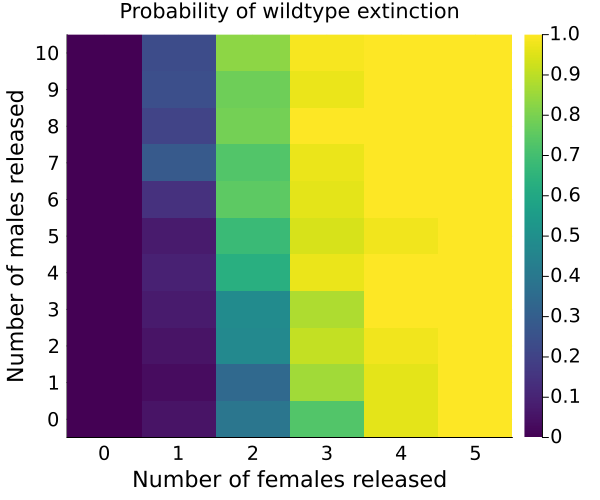

In [13]:
gr()  # backend for heatmap plotting

heatmap_plot = heatmap(
    ratio[:,1:6],
    xlabel = "Number of females released", 
    ylabel = "Number of males released", 
    title = "Probability of wildtype extinction", 
    color = :viridis,
    xticks = (1:6, 0:5),   # sets x and y ticks
    yticks = (1:11, 0:10),
    size = (600, 500), 
    guidefont = font(15), 
    tickfont = font(13),
    grid = true,                # Enable grid lines (tick-aligned)
    gridstyle = :solid,         # Make grid lines solid
    right_margin=5mm,
    foreground_color_grid = :black  # Set grid (tick line) color
)

#savefig(heatmap_plot, "single_mix_rel_inv_prob_50.pdf")
heatmap_plot


Calculates the proportion of time the total metapopulation contains Wolbachia-infected mosquitoes, averaging over all the simulations and excluding the time before releases start (for each different combination of number of males and females released).

In [14]:
num_zeros = zeros(11,6)  # Initialize an array to store the number of zeros in each column

for male in 0:10    # Loop through male release sizes
    for fem in 0:5  # Loop through female release sizes
        JOB_ID = find_job_id(JOBS_DF, fem, male)  # Find the job ID for the current release sizes
        println(fem, "  ", male, "  ", JOB_ID)
        if JOB_ID != nothing  # Check if a valid JOB_ID was found
            df_w = CSV.read(joinpath("../single_rel_mixed_hhold", "$(JOB_ID)", "$(JOB_ID)","w_mosqs_$(H)__$(rel_t)_$(male)_$(fem)_$(rel_type).csv"), DataFrame)
        else # if no valid JOB_ID found
            continue
        end
        wolb_persist = df_w   
        n_rows, n_cols = size(df_w)   # number of rows and columns in the DataFrame

        for col in 1:n_cols  # loops through each column of the DataFrame
            wolb_persist_col = wolb_persist[:, col]
            # find the number of rows in the column that are non-zero and divide by the total 
            # time minus the release time
            num_zeros[male+1,fem+1] += count(!=(0), wolb_persist_col)./ (t_end+1-rel_t)
        end
    end
end
wolb_pers = num_zeros ./ num_simulations  # take the mean for all simulations
println(wolb_pers, "   for release households")

# Save the DataFrame as a CSV file
#CSV.write("wolb_pers_single_mixed.csv", wolb_pers)

0  0  nothing
1  0  1002086
2  0  1002090
3  0  1002099
4  0  1001919
5  0  1002060
0  1  1002087
1  1  1002088
2  1  1002093
3  1  1001911
4  1  1001920
5  1  1002061
0  2  1002092
1  2  1002098
2  2  1002102
3  2  1001912
4  2  1001921
5  2  1002062
0  3  1002101
1  3  1001928
2  3  1001901
3  3  1001913
4  3  1001922
5  3  1002063
0  4  1002131
1  4  1001929
2  4  1001902
3  4  1001914
4  4  1001923
5  4  1002064
0  5  1002132
1  5  1001930
2  5  1001903
3  5  1001915
4  5  1001924
5  5  1002065
0  6  1002110
1  6  1001931
2  6  1001904
3  6  1001916
4  6  1001926
5  6  1002066
0  7  1002145
1  7  1001934
2  7  1001905
3  7  1001917
4  7  1001927
5  7  1001843
0  8  1002112
1  8  1001935
2  8  1001906
3  8  1001918
4  8  1001867
5  8  1001868
0  9  1002113
1  9  1002059
2  9  1001907
3  9  1001878
4  9  1001879
5  9  1001880
0  10  1002114
1  10  1001937
2  10  1001908
3  10  1001890
4  10  1001891
5  10  1001892
[0.0 0.30259694477085775 0.5815981198589895 0.7045945945945944 0.73869

Colour plot for the proportion of time the total metapopulation contains Wolbachia-infected mosquitoes for each release combination of males and females. 

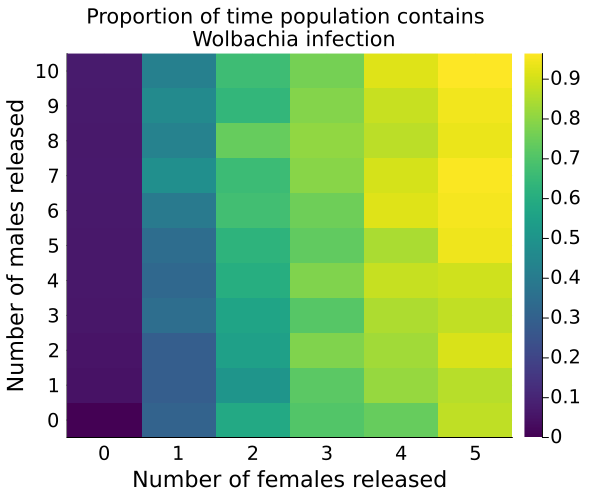

In [15]:
gr()  # backend for heatmap plotting

heatmap_plot = heatmap(
    wolb_pers,
    xlabel = "Number of females released", 
    ylabel = "Number of males released", 
    title = "Proportion of time population contains \n Wolbachia infection", 
    color = :viridis,
    xticks = (1:6, 0:5), 
    yticks = (1:11, 0:10),
    size = (600, 500), 
    guidefont = font(15), 
    tickfont = font(13),
    grid = true,                # Enable grid lines (tick-aligned)
    gridstyle = :solid,         # Make grid lines solid
    foreground_color_grid = :black,  # Set grid (tick line) color
    right_margin=5mm     # Add extra margin to ensure the color bar is fully visible
)

#savefig(heatmap_plot, "single_mix_wolb_pers_propn_50.pdf")
heatmap_plot